In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a Pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target_names'] = iris.target_names[iris.target]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target_names
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


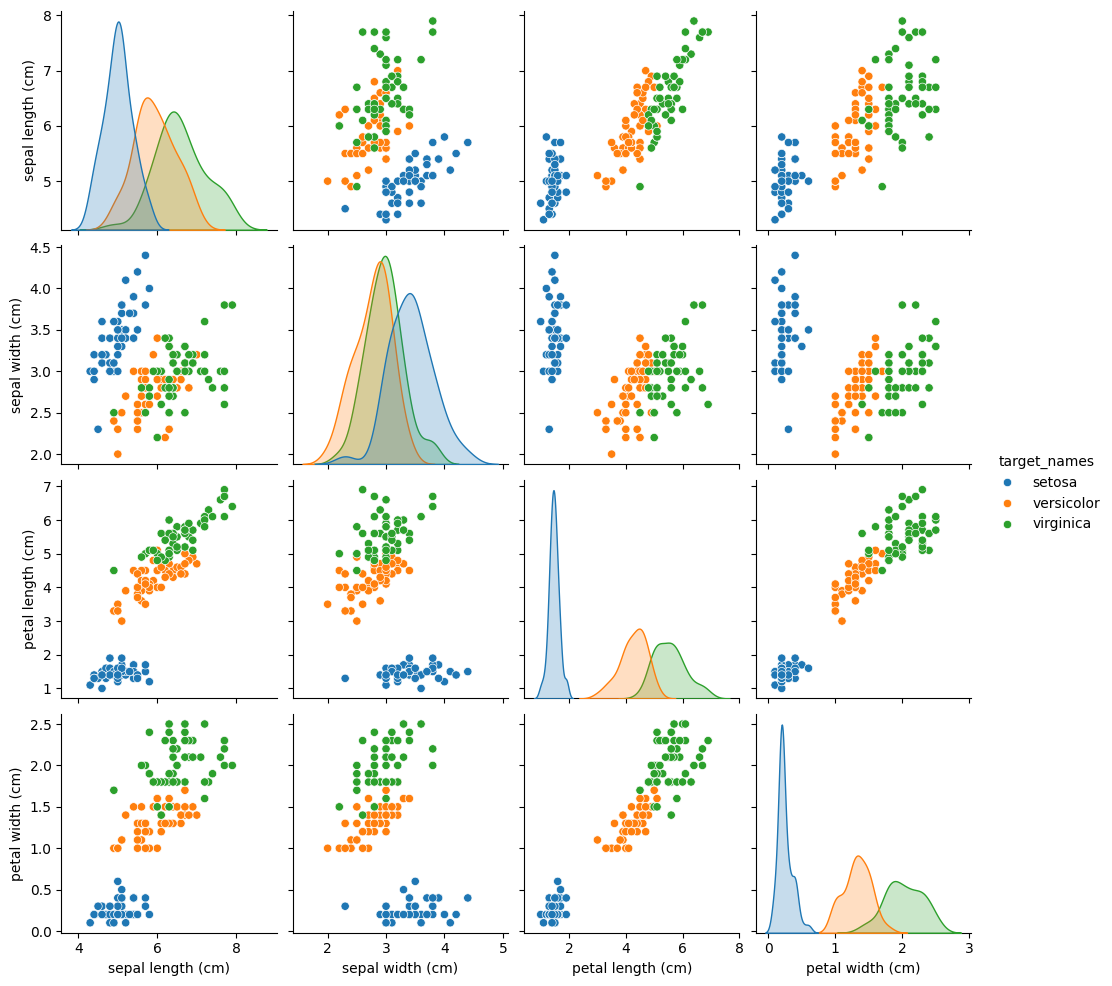

In [3]:
sns.pairplot(df, hue='target_names')
plt.show()

In [4]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target_names'],
      dtype='object')

In [5]:
new_df = df[df['target_names'] != 'setosa'][['sepal length (cm)','sepal width (cm)','target_names']]

In [6]:
new_df.head()

,sepal length (cm),sepal width (cm),target_names
50,7.0,3.2,versicolor
51,6.4,3.2,versicolor
52,6.9,3.1,versicolor
53,5.5,2.3,versicolor
54,6.5,2.8,versicolor


In [7]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, classification_report

In [9]:
clf1 = LogisticRegression()
clf2 = KNeighborsClassifier()
clf3 = RandomForestClassifier()

In [10]:
estimators = [('Lr',clf1),('Knn',clf2),('rf',clf2)]

In [11]:
for estimator in estimators:
  x = cross_val_score(estimator[1],X,y,cv = 10,scoring = 'accuracy')
  print(estimator[0],np.round(np.mean(x),2))

Lr 0.81
Knn 0.76
rf 0.76


In [12]:
from sklearn.ensemble import VotingClassifier

## Hard Voting

In [13]:
vc = VotingClassifier(estimators = estimators)
x = cross_val_score(vc,X,y,cv = 10,scoring = 'accuracy')
print(np.round(np.mean(x),2))

0.76


## Soft Voting

In [14]:
vc = VotingClassifier(estimators = estimators,voting = 'soft')
x = cross_val_score(vc,X,y,cv = 10,scoring = 'accuracy')
print(np.round(np.mean(x),2))

0.77


## Weighted Voting

In [15]:
for i in range(1,4):
  for j in range(1,4):
    for k in range(1,4):
        vc = VotingClassifier(estimators = estimators,voting = 'soft',weights=[i,j,k])
        x = cross_val_score(vc,X,y,cv = 10,scoring = 'accuracy')
        print('for i = {},j = {}, k = {} '.format(i,j,k),np.round(np.mean(x),2))

for i = 1,j = 1, k = 1  0.77
for i = 1,j = 1, k = 2  0.76
for i = 1,j = 1, k = 3  0.76
for i = 1,j = 2, k = 1  0.76
for i = 1,j = 2, k = 2  0.76
for i = 1,j = 2, k = 3  0.76
for i = 1,j = 3, k = 1  0.76
for i = 1,j = 3, k = 2  0.76
for i = 1,j = 3, k = 3  0.76
for i = 2,j = 1, k = 1  0.8
for i = 2,j = 1, k = 2  0.8
for i = 2,j = 1, k = 3  0.77
for i = 2,j = 2, k = 1  0.8
for i = 2,j = 2, k = 2  0.77
for i = 2,j = 2, k = 3  0.76
for i = 2,j = 3, k = 1  0.77
for i = 2,j = 3, k = 2  0.76
for i = 2,j = 3, k = 3  0.76
for i = 3,j = 1, k = 1  0.82
for i = 3,j = 1, k = 2  0.8
for i = 3,j = 1, k = 3  0.8
for i = 3,j = 2, k = 1  0.8
for i = 3,j = 2, k = 2  0.8
for i = 3,j = 2, k = 3  0.8
for i = 3,j = 3, k = 1  0.8
for i = 3,j = 3, k = 2  0.8
for i = 3,j = 3, k = 3  0.77


In [16]:
from sklearn.datasets import make_classification

X,y = make_classification(n_samples = 1000, n_features = 20, n_informative = 15, n_redundant = 5, random_state = 2)

svm1 = SVC(probability=True, kernel='poly', degree=1)
svm2 = SVC(probability=True, kernel='poly', degree=2)
svm3 = SVC(probability=True, kernel='poly', degree=3)
svm4 = SVC(probability=True, kernel='poly', degree=4)
svm5 = SVC(probability=True, kernel='poly', degree=5)

estimators = [('svm1',svm1),('svm2',svm2),('svm3',svm3),('svm4',svm4),('svm5',svm5)]

for estimator in estimators:
  x = cross_val_score(estimator[1],X,y,cv = 10,scoring = 'accuracy')
  print(estimator[0],np.round(np.mean(x),2))

svm1 0.85
svm2 0.85
svm3 0.89
svm4 0.81
svm5 0.86


In [17]:
vc1 = VotingClassifier(estimators = estimators,voting = 'soft')
x = cross_val_score(vc1,X,y,cv = 10,scoring = 'accuracy')
print(np.round(np.mean(x),2))

0.93
